<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Income_Inequality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

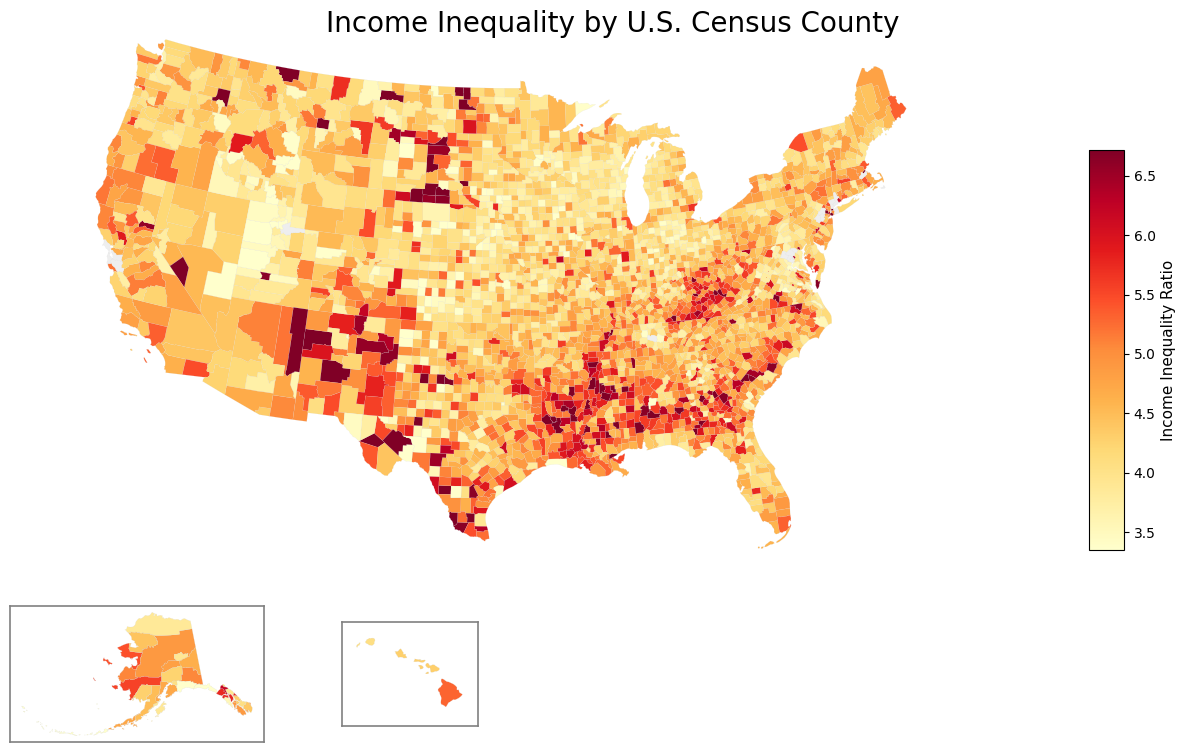

In [2]:
# Run once
# ! pip install matplotlib numpy geopandas pandas openpyxl

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# The Income Ratio compares higher-income households to lower-income households in the same county.
# If the income ratio is 4, a household near the higher-income side,
# the 80th percentile, makes about 4 times as much as a household near the lower-income side, the 20th percentile.

file = "/content/2025 County Health Rankings Data - v4.xlsx"

# Load County Health Rankings data
excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

# Income inequality data
ineq = excel_data[[
    "FIPS",
    "State",
    "County",
    "80th Percentile Income",
    "20th Percentile Income",
    "Income Ratio"
]].copy()

# Keep county rows only, while not removing missing income ratio values
ineq = ineq[ineq["County"].notna()].copy()

# Clean FIPS and Income Ratio column
ineq["FIPS"] = ineq["FIPS"].astype(int).astype(str).str.zfill(5)

ineq["Income Ratio"] = pd.to_numeric(
    ineq["Income Ratio"],
    errors="coerce"
)

# Load county shapefile from U.S. Census Bureau
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

counties = counties.to_crs(epsg=4326)

# Merge county map with income inequality data
merged = counties.merge(
    ineq,
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Color scale
income_values = merged["Income Ratio"].dropna()
vmin = income_values.quantile(0.02)
vmax = income_values.quantile(0.98)

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Main Lower 48 map
ax_main = fig.add_axes([0.03, 0.23, 0.78, 0.70])

lower48_proj.plot(
    column="Income Ratio",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.08,
    vmin=vmin,
    vmax=vmax,
    ax=ax_main,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.08
    }
)

ax_main.axis("off")

# Alaska inset box
ax_ak = fig.add_axes([0.05, 0.02, 0.22, 0.17])
ax_ak.set_facecolor("white")

alaska_proj.plot(
    column="Income Ratio",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_ak,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.12
    }
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.05
y_buffer = (maxy - miny) * 0.05

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Hawaii inset box
ax_hi = fig.add_axes([0.30, 0.04, 0.11, 0.13])
ax_hi.set_facecolor("white")

hawaii_proj.plot(
    column="Income Ratio",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_hi,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.12
    }
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Colorbar
ax_cbar = fig.add_axes([0.84, 0.26, 0.025, 0.50])

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm._A = []

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label("Income Inequality Ratio", fontsize=11)

# Title
fig.suptitle(
    "Income Inequality by U.S. Census County",
    fontsize=20,
    y=0.935
)

plt.show()